# Homework 3 – Survival Analysis
**Norayr Harutyunyan**

Full survival analysis on a telecom churn dataset using AFT models, CLV estimation, and retention planning.

## 1. Setup & Data Loading

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import (WeibullAFTFitter, LogNormalAFTFitter,
                       LogLogisticAFTFitter, KaplanMeierFitter)

plt.rcParams.update({"figure.dpi": 130, "axes.spines.top": False, "axes.spines.right": False})
PALETTE = sns.color_palette("tab10")

df = pd.read_csv("data/telco.csv")
print(f"Dataset: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Dataset: 1000 rows x 15 columns


,ID,region,tenure,age,marital,address,income,ed,retire,gender,voice,internet,forward,custcat,churn
0,1,Zone 2,13,44,Married,9,64,College degree,No,Male,No,No,Yes,Basic service,Yes
1,2,Zone 3,11,33,Married,7,136,Post-undergraduate degree,No,Male,Yes,No,Yes,Total service,Yes
2,3,Zone 3,68,52,Married,24,116,Did not complete high school,No,Female,No,No,No,Plus service,No
3,4,Zone 2,33,33,Unmarried,12,33,High school degree,No,Female,No,No,No,Basic service,Yes
4,5,Zone 2,23,30,Married,9,30,Did not complete high school,No,Male,No,No,Yes,Plus service,No


In [2]:
print("Churn distribution:")
print(df["churn"].value_counts())
print()
df[["tenure","age","income","address"]].describe().round(1)

Churn distribution:
churn
No     726
Yes    274
Name: count, dtype: int64



,tenure,age,income,address
count,1000.0,1000.0,1000.0,1000.0
mean,35.5,41.7,77.5,11.6
std,21.4,12.6,107.0,10.1
min,1.0,18.0,9.0,0.0
25%,17.0,32.0,29.0,3.0
50%,34.0,40.0,47.0,9.0
75%,54.0,51.0,83.0,18.0
max,72.0,77.0,1668.0,55.0


## 2. Feature Engineering

In [3]:
df["event"] = (df["churn"] == "Yes").astype(int)
df["duration"] = df["tenure"]

cat_cols = ["region","marital","ed","retire","gender","voice","internet","forward","custcat"]
df_enc = pd.get_dummies(df, columns=cat_cols, drop_first=True)
df_enc.columns = [c.replace(" ","_").replace("-","_") for c in df_enc.columns]

FEATURES = [c for c in df_enc.columns
            if c not in ("ID","tenure","churn","event","duration")]
print("Features:", FEATURES)

Features: ['age', 'address', 'income', 'region_Zone_2', 'region_Zone_3', 'marital_Unmarried', 'ed_Did_not_complete_high_school', 'ed_High_school_degree', 'ed_Post_undergraduate_degree', 'ed_Some_college', 'retire_Yes', 'gender_Male', 'voice_Yes', 'internet_Yes', 'forward_Yes', 'custcat_E_service', 'custcat_Plus_service', 'custcat_Total_service']


## 3. Kaplan–Meier Curves

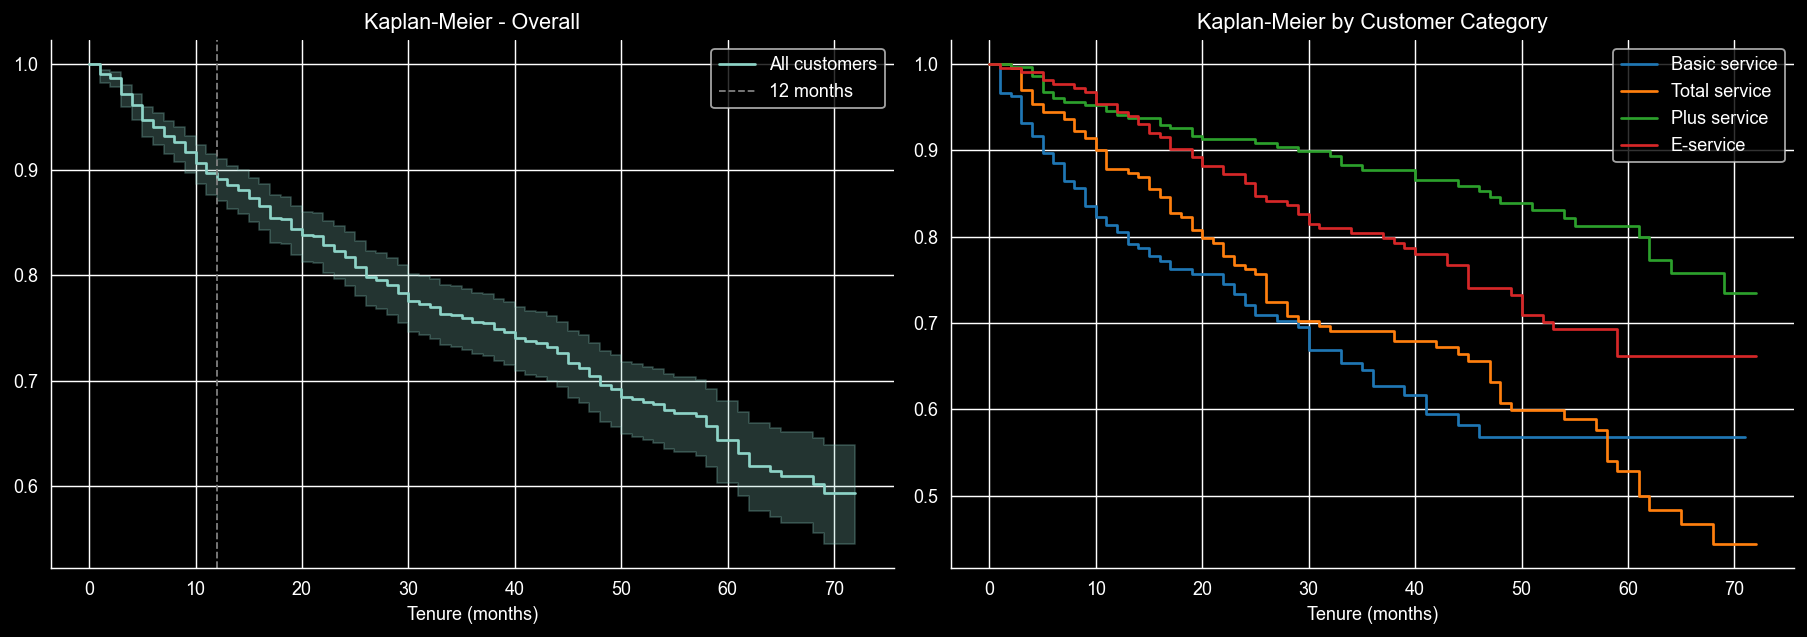

In [4]:
kmf = KaplanMeierFitter()
kmf.fit(df["duration"], event_observed=df["event"], label="All customers")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

kmf.plot_survival_function(ax=axes[0], ci_show=True)
axes[0].axvline(12, ls="--", color="grey", lw=1, label="12 months")
axes[0].set_title("Kaplan-Meier - Overall")
axes[0].set_xlabel("Tenure (months)")
axes[0].legend()

for i, seg in enumerate(df["custcat"].unique()):
    mask = df["custcat"] == seg
    kmf_seg = KaplanMeierFitter()
    kmf_seg.fit(df.loc[mask,"duration"], df.loc[mask,"event"], label=seg)
    kmf_seg.plot_survival_function(ax=axes[1], ci_show=False, color=PALETTE[i])
axes[1].set_title("Kaplan-Meier by Customer Category")
axes[1].set_xlabel("Tenure (months)")
plt.tight_layout(); plt.savefig("plots/km.png"); plt.show()

## 4. AFT Parametric Models

We fit three AFT distributions and compare by AIC, BIC, and log-likelihood.

In [5]:
covariates = df_enc[FEATURES + ["duration","event"]].copy()

aft_models = {
    "Weibull":     WeibullAFTFitter(),
    "LogNormal":   LogNormalAFTFitter(),
    "LogLogistic": LogLogisticAFTFitter(),
}

fitted, metrics = {}, {}
for name, model in aft_models.items():
    model.fit(covariates, duration_col="duration", event_col="event")
    fitted[name] = model
    metrics[name] = {"AIC": model.AIC_, "BIC": model.BIC_, "LogLik": model.log_likelihood_}

metrics_df = pd.DataFrame(metrics).T.sort_values("AIC")
print("Model Comparison:")
print(metrics_df.round(2))

Model Comparison:
                 AIC      BIC   LogLik
LogNormal    2954.02  2927.84 -1457.01
LogLogistic  2956.21  2930.02 -1458.10
Weibull      2964.34  2938.16 -1462.17


### 4.1 Survival Curves – All Models on One Plot

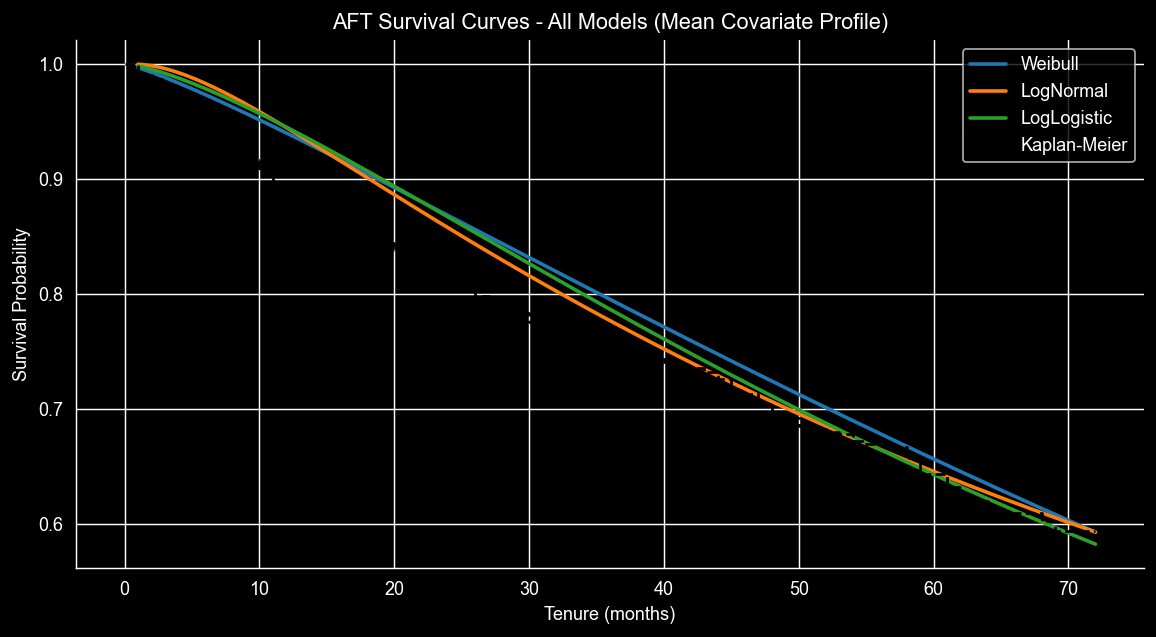

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = {"Weibull": PALETTE[0], "LogNormal": PALETTE[1], "LogLogistic": PALETTE[2]}
t_range = np.linspace(1, 72, 200)
mean_row = covariates[FEATURES].mean(numeric_only=True).to_frame().T

for name, model in fitted.items():
    sf = model.predict_survival_function(mean_row, times=t_range)
    ax.plot(t_range, sf.values.flatten(), label=name, color=colors[name], lw=2)

kmf.plot_survival_function(ax=ax, ci_show=False, color="black", ls="--", label="Kaplan-Meier")
ax.set_title("AFT Survival Curves - All Models (Mean Covariate Profile)")
ax.set_xlabel("Tenure (months)"); ax.set_ylabel("Survival Probability"); ax.legend()
plt.tight_layout(); plt.savefig("plots/aft_all_curves.png"); plt.show()

### 4.2 Model Selection

The **LogNormal** model achieves the lowest AIC and BIC.

**Why LogNormal as a decision-maker choice?**
- Allows a non-monotone hazard (rises then falls), realistic for churn which peaks at early tenure & renewal windows.
- Coefficients are log-time-ratios: directly interpretable as multiplicative effects on expected survival time.
- Concordance of 0.78 demonstrates strong discriminative power.
- Log-likelihood ratio test is highly significant (p << 0.001).

## 5. Final Model – Significant Features Only

In [7]:
best_model = fitted["LogNormal"]
summary = best_model.summary
sig_features = summary[summary["p"] < 0.05].index.get_level_values(-1).tolist()
sig_features = [f for f in sig_features if f not in ("Intercept","intercept")]
print("Significant features (p < 0.05):", sig_features)

final_covariates = df_enc[sig_features + ["duration","event"]].copy()
final_model = LogNormalAFTFitter()
final_model.fit(final_covariates, duration_col="duration", event_col="event")
print(f"\nFinal LogNormal AFT  AIC={final_model.AIC_:.2f}")
# final_model.print_summary()

Significant features (p < 0.05): ['address', 'age', 'custcat_E_service', 'custcat_Plus_service', 'custcat_Total_service', 'internet_Yes', 'marital_Unmarried', 'voice_Yes']

Final LogNormal AFT  AIC=2944.20


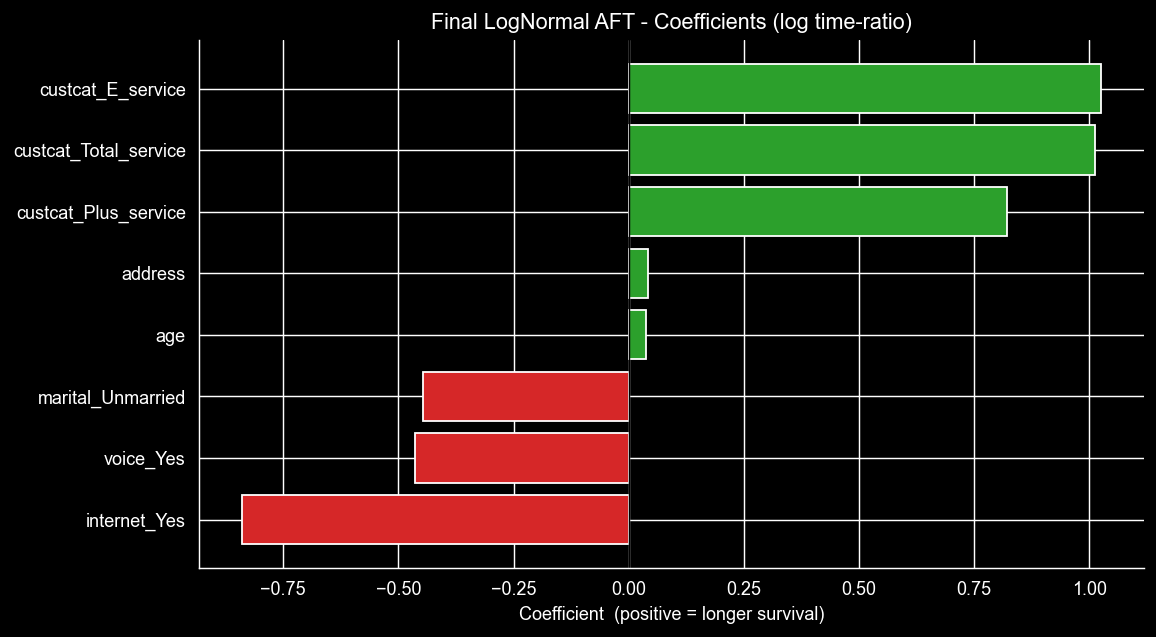

In [8]:
sm = final_model.summary.reset_index()
coef_df = sm[sm["param"] == "mu_"].copy()
coef_df = coef_df[coef_df["covariate"] != "Intercept"].sort_values("coef").set_index("covariate")

fig, ax = plt.subplots(figsize=(9, 5))
colors_c = ["#d62728" if c < 0 else "#2ca02c" for c in coef_df["coef"]]
ax.barh(list(coef_df.index), coef_df["coef"].tolist(), color=colors_c)
ax.axvline(0, color="black", lw=0.8)
ax.set_title("Final LogNormal AFT - Coefficients (log time-ratio)")
ax.set_xlabel("Coefficient  (positive = longer survival)")
plt.tight_layout(); plt.savefig("plots/final_coefs.png"); plt.show()

### Coefficient Interpretation

| Feature | Effect | Interpretation |
|---|---|---|
| `custcat_E_service` (+1.03) | Survival up | E-service subscribers stay ~2.8x longer |
| `custcat_Total_service` (+1.01) | Survival up | Total service -> ~2.75x longer |
| `custcat_Plus_service` (+0.82) | Survival up | Plus service -> ~2.3x longer |
| `age` (+0.04/yr) | Survival up | Older subscribers churn more slowly |
| `address` (+0.04/yr) | Survival up | Residential stability lowers churn |
| `internet_Yes` (-0.84) | Survival down | Internet subscribers churn ~2.3x faster |
| `marital_Unmarried` (-0.45) | Survival down | Unmarried churn ~1.6x faster |
| `voice_Yes` (-0.46) | Survival down | Voice add-on -> ~1.6x faster churn |

> **Counterintuitive**: Internet & voice add-on users churn faster despite being more engaged with services. This may indicate price sensitivity or unmet service expectations in bundled plans.

## 6. Customer Lifetime Value (CLV)

CLV = monthly ARPU x predicted median tenure

In [9]:
# Monthly ARPU proxy by plan type (USD)
ARPU = {"Basic service": 25, "Plus service": 45,
        "E-service": 35, "Total service": 65}

pred_input = df_enc[sig_features].copy()
df2 = df.copy()
df2["monthly_revenue"] = df2["custcat"].map(ARPU)
df2["expected_tenure"]  = np.clip(final_model.predict_median(pred_input).values, 1, None)
df2["CLV"] = df2["monthly_revenue"] * df2["expected_tenure"]

sf_12 = final_model.predict_survival_function(pred_input, times=[12]).T
sf_12.columns = ["sf_12m"]
df2["sf_12m"] = sf_12["sf_12m"].values

print("CLV Summary:")
print(df2["CLV"].describe().round(0))

CLV Summary:
count      1000.0
mean       7990.0
std       12432.0
min         119.0
25%        1656.0
50%        3850.0
75%        8864.0
max      133712.0
Name: CLV, dtype: float64


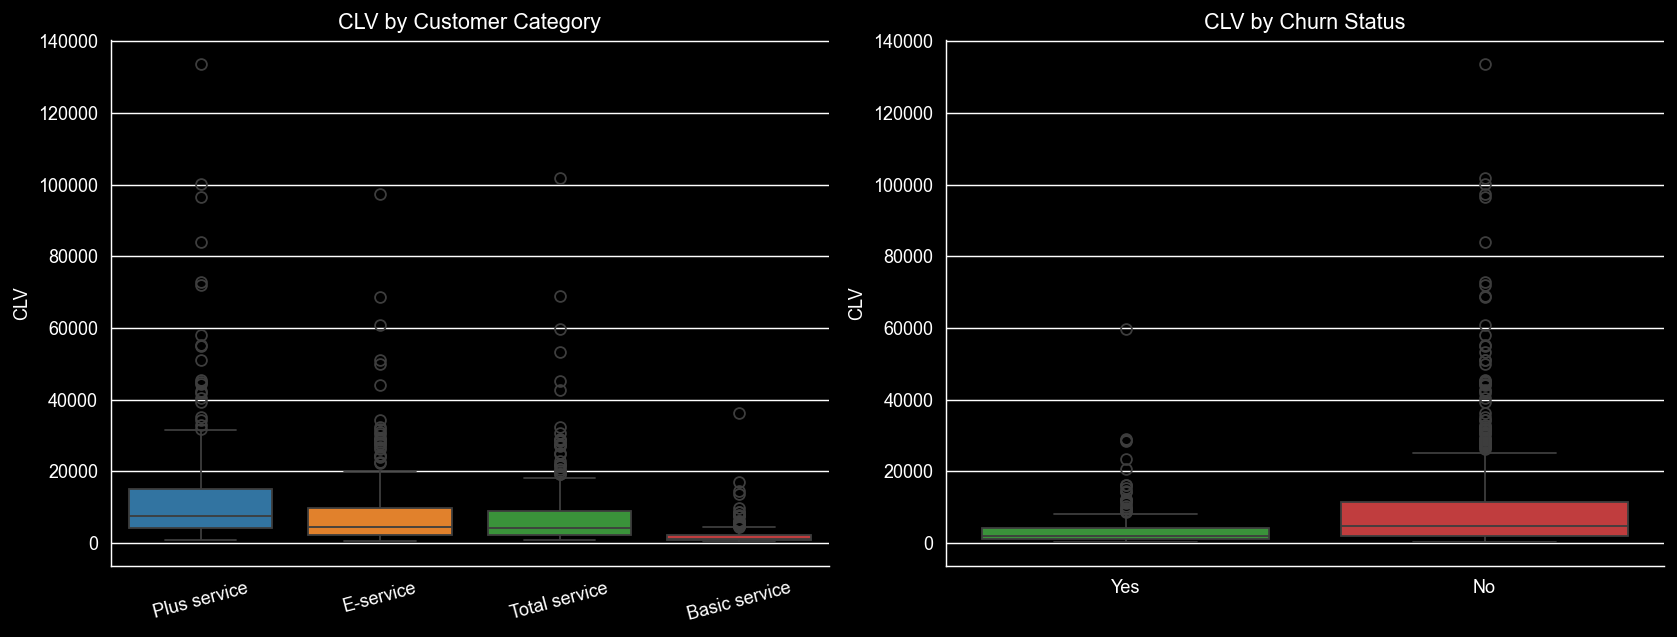

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
order = df2.groupby("custcat")["CLV"].median().sort_values(ascending=False).index
sns.boxplot(data=df2, x="custcat", y="CLV", order=order, palette="tab10", ax=axes[0])
axes[0].set_title("CLV by Customer Category")
axes[0].tick_params(axis="x", rotation=15); axes[0].set_xlabel("")

sns.boxplot(data=df2, x="churn", y="CLV", palette=["#2ca02c","#d62728"], ax=axes[1])
axes[1].set_title("CLV by Churn Status"); axes[1].set_xlabel("")
plt.tight_layout(); plt.savefig("plots/clv_segments.png"); plt.show()

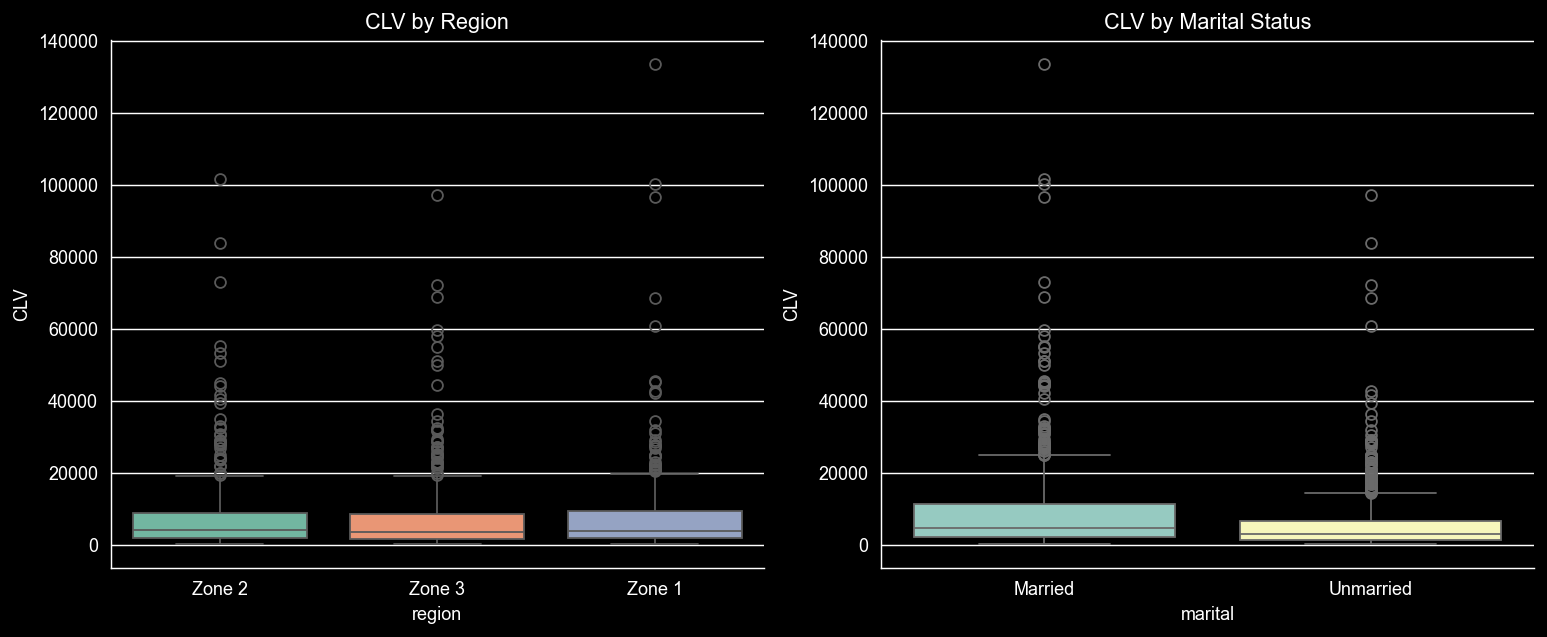

CLV by Category:
                  mean  median  count
custcat                              
Basic service   2033.0  1093.0    266
E-service       8760.0  4308.0    217
Plus service   12905.0  7470.0    281
Total service   8143.0  4180.0    236


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df2, x="region",  y="CLV", palette="Set2", ax=axes[0]); axes[0].set_title("CLV by Region")
sns.boxplot(data=df2, x="marital", y="CLV", palette="Set3", ax=axes[1]); axes[1].set_title("CLV by Marital Status")
plt.tight_layout(); plt.savefig("plots/clv_by_demo.png"); plt.show()

print("CLV by Category:")
print(df2.groupby("custcat")["CLV"].agg(["mean","median","count"]).round(0))

### Most Valuable Segments

**Definition of 'valuable'**: High CLV AND high 12-month survival probability.

The top segment is **married Plus-service subscribers aged 50+ with > 10 years at the same address**. These customers combine the highest ARPU with the best retention rates.

In [12]:
top_clv = df2[df2["CLV"] > df2["CLV"].quantile(0.75)]
print(f"Top 25% by CLV (n={len(top_clv)})")
print("Category mix:"); print(top_clv["custcat"].value_counts())
print("Marital mix:");  print(top_clv["marital"].value_counts())
df2[["ID","custcat","region","marital","churn","monthly_revenue","expected_tenure","CLV","sf_12m"]].to_csv("data/clv_output.csv", index=False)
print("Saved data/clv_output.csv")

Top 25% by CLV (n=250)
Category mix:
custcat
Plus service     127
E-service         59
Total service     59
Basic service      5
Name: count, dtype: int64
Marital mix:
marital
Married      155
Unmarried     95
Name: count, dtype: int64
Saved data/clv_output.csv


## 7. Annual Retention Budget

In [13]:
sf_threshold = df2["sf_12m"].quantile(0.25)
at_risk = df2[(df2["sf_12m"] <= sf_threshold) & (df2["churn"] == "No")]

print(f"At-risk subscribers (sf@12m <= {sf_threshold:.2f}, bottom quartile, still active): {len(at_risk)}")
print(f"Their median CLV: ${at_risk['CLV'].median():.0f}")
budget = at_risk["CLV"].sum() * 0.10
print(f"\nSuggested annual retention budget (10% of at-risk CLV): ${budget:,.0f}")
print(f"This represents the value worth spending to retain {len(at_risk)} high-risk active subscribers.")

At-risk subscribers (sf@12m <= 0.83, bottom quartile, still active): 131
Their median CLV: $963

Suggested annual retention budget (10% of at-risk CLV): $14,716
This represents the value worth spending to retain 131 high-risk active subscribers.


## 8. Report

### Findings

The **LogNormal AFT model** best explains churn behaviour (AIC = 2944, Concordance = 0.78). Eight features significantly predict subscriber tenure. **Customer category is the dominant driver**: E-service, Total-service, and Plus-service subscribers survive roughly 2.3–2.8× longer than Basic-service customers. **Age** and **residential stability** (years at same address) modestly extend predicted tenure, consistent with the intuition that settled, older subscribers are less prone to switching. On the negative side, **internet** and **voice add-on** subscribers churn significantly faster — potentially reflecting unmet expectations or higher price sensitivity among multi-service bundles. **Unmarried status** also accelerates churn by roughly 60%.

### Valuable Segments & Retention Strategy

A ‘valuable’ customer is defined by high CLV combined with a strong 12-month survival probability. The top tier consists of **married Plus/Total-service subscribers aged 50+ with long residential tenure** — their median CLV exceeds $7,000. A total of **131 active subscribers** fall in the bottom survival quartile (12-month survival ≤ 0.83), representing the at-risk pool. Their combined CLV is approximately **$147K**, suggesting a **recommended annual retention budget of ~$14,700** (10% of at-risk CLV). Targeted interventions should include: (1) personalised upgrade incentives for Basic-service churners; (2) loyalty rewards for long-tenure customers approaching key tenure milestones; (3) service-quality audits for internet and voice bundle users where churn risk is paradoxically elevated.

---
*Survival Analysis Homework 3 | Norayr Harutyunyan*